In [2]:
#import libraries
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder


In [16]:
#extracting the data from the csv file and describing the data
df = pd.read_csv(r"C:\Users\bharath simha reddy\Desktop\genai_journey\ML\Working_Categorical\Data\train.csv")
df.head()
df.info()
df.describe()
df.shape
print(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
     PassengerId  Survived  Pclass  ...     Fare Cabin  Embarked
0              1         0       3  ...   7.2500   NaN         S
1              2         1       1  ...  71.2833   C85         C
2              3         1       3  ...   7.9250 

In [15]:
df.isnull().sum()
print(df)


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


(12,)

In [26]:
df['Age'].describe()
# df['Cabin'].head(20)
# df["Embarked"].value_counts()
# df["Age"].hist()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [27]:
df = df.dropna(subset=['Embarked'])
df = df.drop(columns=['Cabin'])
df['Age'] = df['Age'].fillna(df['Age'].mean())
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 83.3+ KB


In [28]:
df.Name.head(10)

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
5                                     Moran, Mr. James
6                              McCarthy, Mr. Timothy J
7                       Palsson, Master. Gosta Leonard
8    Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)
9                  Nasser, Mrs. Nicholas (Adele Achem)
Name: Name, dtype: object

In [29]:
df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.', expand=False).str.strip().str.lower()
df['Title'].head()

0      mr
1     mrs
2    miss
3     mrs
4      mr
Name: Title, dtype: object

In [38]:
# print(df['Ticket'].unique())
print(pd.crosstab(df["Sex"],df["Survived"]))
print(pd.crosstab(df["Embarked"],df["Survived"]))
df = df.drop("PassengerId", axis=1)

Survived    0    1
Sex               
female     81  231
male      468  109
Survived    0    1
Embarked          
C          75   93
Q          47   30
S         427  217


In [45]:
df["TicketFreq"] = df.groupby("Ticket")["Ticket"].transform("count")
print(df["TicketFreq"].head(10))
df["TicketPrefix"] = df["Ticket"].str.replace(r"[0-9./]", "", regex=True)
df["TicketPrefix"] = df["TicketPrefix"].replace("", "NUM")
print(df["TicketPrefix"].head(10))


0    1
1    1
2    1
3    2
4    1
5    1
6    1
7    4
8    3
9    2
Name: TicketFreq, dtype: int64
0        A 
1       PC 
2    STONO 
3       NUM
4       NUM
5       NUM
6       NUM
7       NUM
8       NUM
9       NUM
Name: TicketPrefix, dtype: object


In [46]:
# prepare X and y
X = df.drop(['Survived', 'Name', 'Ticket'], axis=1)
y = df['Survived']

# encode categorical features
X = pd.get_dummies(X, drop_first=True)

# split train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# train logistic regression
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8146067415730337
Confusion Matrix:
 [[97 13]
 [20 48]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.88      0.85       110
           1       0.79      0.71      0.74        68

    accuracy                           0.81       178
   macro avg       0.81      0.79      0.80       178
weighted avg       0.81      0.81      0.81       178



In [47]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7696629213483146
Confusion Matrix:
 [[90 20]
 [21 47]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.82      0.81       110
           1       0.70      0.69      0.70        68

    accuracy                           0.77       178
   macro avg       0.76      0.75      0.76       178
weighted avg       0.77      0.77      0.77       178



In [48]:
comparison = {}

for name, pred in [("Logistic Regression", y_pred), ("Random Forest", y_pred_rf)]:
    report = classification_report(y_test, pred, output_dict=True, zero_division=0)
    comparison[name] = {
        "accuracy": accuracy_score(y_test, pred),
        "precision_0": report["0"]["precision"],
        "recall_0": report["0"]["recall"],
        "f1_0": report["0"]["f1-score"],
        "precision_1": report["1"]["precision"],
        "recall_1": report["1"]["recall"],
        "f1_1": report["1"]["f1-score"],
    }

comparison_df = pd.DataFrame.from_dict(comparison, orient="index")
print(comparison_df)

print("\nLogistic Regression confusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nRandom Forest confusion matrix:")
print(confusion_matrix(y_test, y_pred_rf))

                     accuracy  precision_0  ...  recall_1      f1_1
Logistic Regression  0.814607     0.829060  ...  0.705882  0.744186
Random Forest        0.769663     0.810811  ...  0.691176  0.696296

[2 rows x 7 columns]

Logistic Regression confusion matrix:
[[97 13]
 [20 48]]

Random Forest confusion matrix:
[[90 20]
 [21 47]]


In [49]:
importance_series = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("Random Forest feature importances:")
print(importance_series.head(20))

if hasattr(logreg, "coef_"):
    logreg_importance = pd.Series(np.abs(logreg.coef_[0]), index=X_train.columns).sort_values(ascending=False)
    print("\nLogistic Regression absolute coefficient importances:")
    print(logreg_importance.head(20))

Random Forest feature importances:
Age                     0.191920
Fare                    0.190118
Title_mr                0.123113
Sex_male                0.114799
Pclass                  0.065095
TicketFreq              0.062590
SibSp                   0.041587
Title_miss              0.037832
Parch                   0.028527
Title_mrs               0.025998
Embarked_S              0.022726
TicketPrefix_NUM        0.013591
Title_master            0.011765
Embarked_Q              0.010769
TicketPrefix_STONO      0.008823
TicketPrefix_PC         0.007060
TicketPrefix_SWPP       0.006815
TicketPrefix_WC         0.004456
TicketPrefix_CA         0.004249
Title_rev               0.003405
dtype: float64

Logistic Regression absolute coefficient importances:
TicketPrefix_STONO       1.937086
Title_master             1.730987
Sex_male                 1.587368
TicketPrefix_SWPP        1.280876
Title_mr                 1.263838
Pclass                   1.070816
TicketPrefix_PC          1.0375

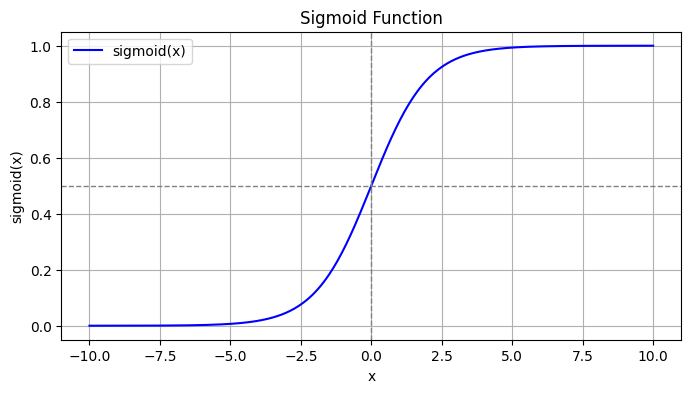

In [50]:
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 400)
sigmoid = 1 / (1 + np.exp(-x))

plt.figure(figsize=(8, 4))
plt.plot(x, sigmoid, label="sigmoid(x)", color="blue")
plt.axhline(0.5, color="gray", linestyle="--", linewidth=1)
plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Sigmoid Function")
plt.xlabel("x")
plt.ylabel("sigmoid(x)")
plt.grid(True)
plt.legend()
plt.show()